In [27]:
from wtmm.colormaps import lastwave_colormap, lastwave_grey_colormap, lastwave_b2r_colormap, scalogram_lastwave
import matplotlib.pyplot as plt

# Register colormaps globally so they can be used by name
_lw_cmap = lastwave_colormap(256)
_lw_grey = lastwave_grey_colormap(256)
_lw_b2r = lastwave_b2r_colormap(256)
try:
    plt.colormaps.register(_lw_cmap)
    plt.colormaps.register(_lw_grey)
    plt.colormaps.register(_lw_b2r)
except ValueError:
    pass  # already registered

print("LastWave plotting utilities loaded:")
print("  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'")
print("  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)")
print(f"              norm_mode='lglobal' (default) | 'global' | 'signedglobal'")
print(f"  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)")

LastWave plotting utilities loaded:
  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'
  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)
              norm_mode='lglobal' (default) | 'global' | 'signedglobal'
  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)


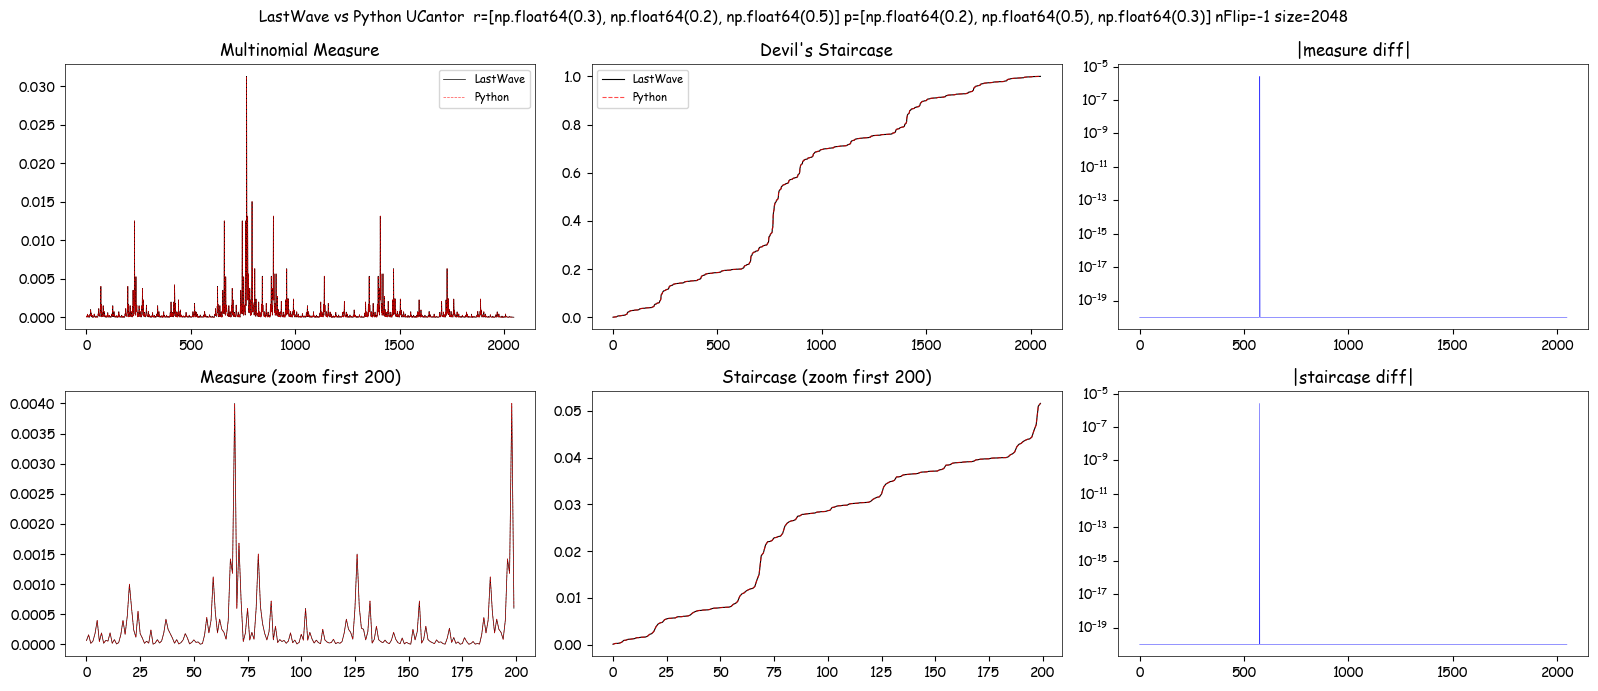

Max |measure diff|:   2.59e-06
Max |staircase diff|: 2.59e-06
Staircase range LW:   [0.000064, 1.000000]
Staircase range Py:   [0.000064, 1.000000]


In [28]:
# LastWave ground truth — Step 1: Inhomogeneous devil's staircase (LastWave vs Python)
import ctypes, ctypes.util, numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Force reload the dylib (kernel may cache old version)
_lw_path = './liblastwave_wrapper.dylib'
try:
    ctypes.cdll.LoadLibrary(_lw_path)
except:
    pass
lib = ctypes.CDLL(_lw_path)

lib.lw_init.restype = ctypes.c_int
lib.lw_ucantor.restype = ctypes.c_int
lib.lw_ucantor.argtypes = [ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.c_int, ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double)]
lib.lw_cleanup.restype = None
lib.lw_get_error.restype = ctypes.c_char_p
lib.lw_eval_wavelet.restype = ctypes.c_int
lib.lw_get_wavelet_domain.restype = ctypes.c_int

c_double_p = ctypes.POINTER(ctypes.c_double)

ret = lib.lw_init()
assert ret == 0, f"lw_init failed: {lib.lw_get_error()}"

# ── DemoWTMM1DDevilStair parameters ──
SIZE = 2048
r = np.array([0.3, 0.2, 0.5], dtype=np.float64)
p = np.array([0.2, 0.5, 0.3], dtype=np.float64)
nFlip = -1  # no flip (matches C_UCantor doing nFlip-- from 0)

# ── LastWave UCantor ──
lw_measure = np.zeros(SIZE, dtype=np.float64)
ret = lib.lw_ucantor(SIZE, r.ctypes.data_as(c_double_p),
                      p.ctypes.data_as(c_double_p), 3, nFlip,
                      lw_measure.ctypes.data_as(c_double_p))
assert ret == 0, f"lw_ucantor failed: {lib.lw_get_error()}"
lw_staircase = np.cumsum(lw_measure)

# ── Python UCantor (same algorithm as cell 6) ──
from wtmm.signals import ucantor

py_measure, _ = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)
py_staircase = np.cumsum(py_measure)

# ── Compare ──
measure_diff = np.abs(lw_measure - py_measure)
stair_diff = np.abs(lw_staircase - py_staircase)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

axes[0, 0].plot(lw_measure, 'k-', lw=0.5, label='LastWave')
axes[0, 0].plot(py_measure, 'r--', lw=0.5, alpha=0.7, label='Python')
axes[0, 0].set_title('Multinomial Measure')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(lw_staircase, 'k-', lw=0.8, label='LastWave')
axes[0, 1].plot(py_staircase, 'r--', lw=0.8, alpha=0.7, label='Python')
axes[0, 1].set_title("Devil's Staircase")
axes[0, 1].legend(fontsize=8)

axes[0, 2].semilogy(measure_diff + 1e-20, 'b-', lw=0.3)
axes[0, 2].set_title('|measure diff|')

axes[1, 0].plot(lw_measure[:200], 'k-', lw=0.5)
axes[1, 0].plot(py_measure[:200], 'r--', lw=0.5, alpha=0.7)
axes[1, 0].set_title('Measure (zoom first 200)')

axes[1, 1].plot(lw_staircase[:200], 'k-', lw=0.8)
axes[1, 1].plot(py_staircase[:200], 'r--', lw=0.8, alpha=0.7)
axes[1, 1].set_title('Staircase (zoom first 200)')

axes[1, 2].semilogy(stair_diff + 1e-20, 'b-', lw=0.3)
axes[1, 2].set_title('|staircase diff|')

plt.suptitle(f'LastWave vs Python UCantor  r={list(r)} p={list(p)} nFlip={nFlip} size={SIZE}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Max |measure diff|:   {measure_diff.max():.2e}')
print(f'Max |staircase diff|: {stair_diff.max():.2e}')
print(f'Staircase range LW:   [{lw_staircase.min():.6f}, {lw_staircase.max():.6f}]')
print(f'Staircase range Py:   [{py_staircase.min():.6f}, {py_staircase.max():.6f}]')

Start octave 1.........
Start octave 2.........
Start octave 3.........
Start octave 4.........
Start octave 5.........


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_31705/595811681.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()
/Users/amasaryk/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


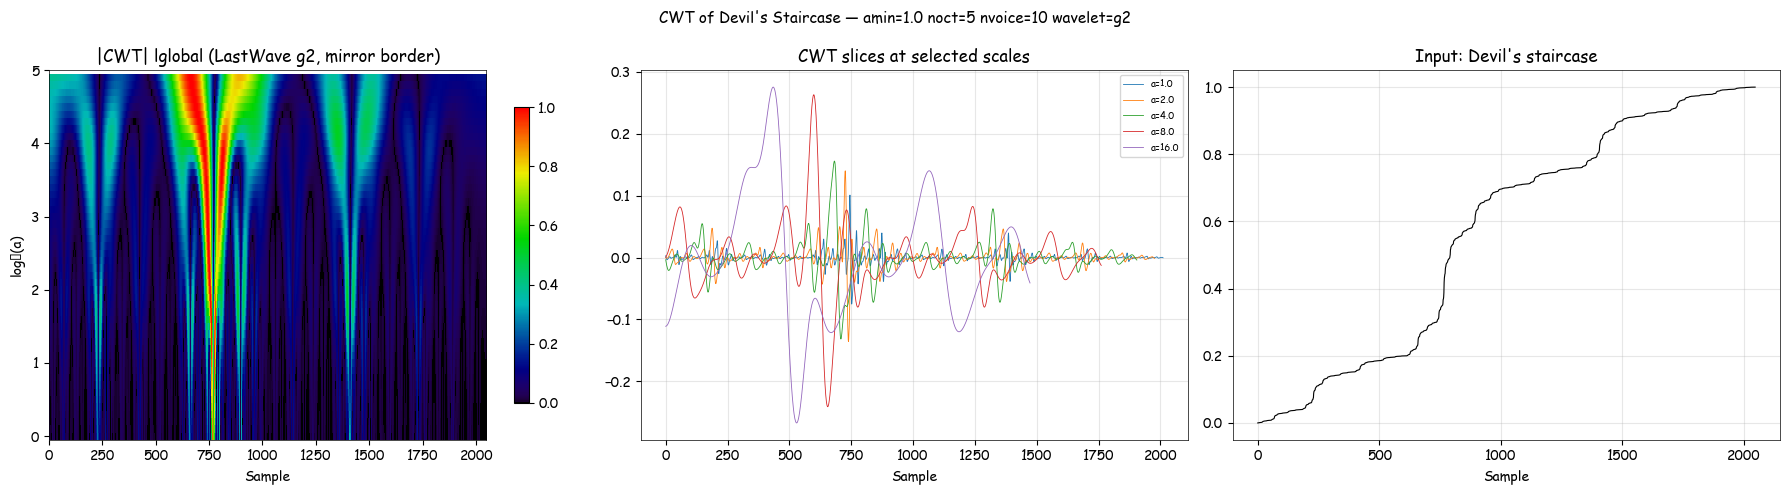

Scales: 50 total, range [1.00, 29.86]
  scale  0 (a=   1.00): valid range [18, 2029]
  scale 10 (a=   2.00): valid range [35, 2012]
  scale 20 (a=   4.00): valid range [71, 1976]
  scale 30 (a=   8.00): valid range [143, 1904]
  scale 40 (a=  16.00): valid range [287, 1760]


In [29]:
# LastWave ground truth — Step 2: CWT of inhomogeneous Cantor measure via LastWave
#
# DemoWTMM1DDevilStair params: amin=1.0, omax=5, nvoice=10, wavelet='g2', border='mir'
# The input is the devil's staircase (integrated measure) from cell 0.

# ── CWT setup ──
lib.lw_cwtd.restype = ctypes.c_int
lib.lw_cwtd.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # signal_in
    ctypes.c_int,                      # size
    ctypes.c_double,                   # a_min
    ctypes.c_int,                      # n_oct
    ctypes.c_int,                      # n_voice
    ctypes.c_char_p,                   # wavelet_name
    ctypes.c_double,                   # expo
    ctypes.c_int,                      # border_type
    ctypes.POINTER(ctypes.c_double),   # coeffs_out
    ctypes.POINTER(ctypes.c_int),      # firstp_out
    ctypes.POINTER(ctypes.c_int),      # lastp_out
]

a_min   = 1.0
n_oct   = 5
n_voice = 10
wavelet = b'g2'
expo    = -1.0
border  = 1       # CV_MIRROR (enum: CV_PERIODIC=0, CV_MIRROR=1, CV_PADDING=2, CV_0_PADDING=3)

n_scales = n_oct * n_voice
coeffs  = np.zeros(n_scales * SIZE, dtype=np.float64)
firstp  = np.zeros(n_scales, dtype=np.int32)
lastp   = np.zeros(n_scales, dtype=np.int32)

# CWT of the devil's staircase (= cumsum of measure), matching the demo's "0w = prim(0w)"
ret = lib.lw_cwtd(
    lw_staircase.ctypes.data_as(c_double_p), SIZE,
    ctypes.c_double(a_min), n_oct, n_voice,
    wavelet, ctypes.c_double(expo), border,
    coeffs.ctypes.data_as(c_double_p),
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
assert ret == 0, f"lw_cwtd failed: {lib.lw_get_error()}"

cwt = coeffs.reshape(n_scales, SIZE)

# ── Scale axis ──
factor = 2.0 ** (1.0 / n_voice)
scales = a_min * factor ** np.arange(n_scales)
log2_scales = np.log2(scales)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Scalogram (LastWave lglobal normalization — per-scale-line, no log)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('|CWT| lglobal (LastWave g2, mirror border)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# CWT at a few selected scales
sel = [0, n_voice, 2*n_voice, 3*n_voice, 4*n_voice]
for s in sel:
    fp, lp = firstp[s], lastp[s]
    axes[1].plot(cwt[s, fp:lp+1], lw=0.6, label=f'a={scales[s]:.1f}')
axes[1].set_title('CWT slices at selected scales')
axes[1].set_xlabel('Sample')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Devil's staircase for reference
axes[2].plot(lw_staircase, 'k-', lw=0.8)
axes[2].set_title("Input: Devil's staircase")
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"CWT of Devil's Staircase — amin={a_min} noct={n_oct} nvoice={n_voice} wavelet=g2", fontsize=11)
plt.tight_layout()
plt.show()

# ── Valid range info ──
print(f'Scales: {n_scales} total, range [{scales[0]:.2f}, {scales[-1]:.2f}]')
for s in sel:
    print(f'  scale {s:2d} (a={scales[s]:7.2f}): valid range [{firstp[s]}, {lastp[s]}]')

Total extrema found: 3645
Extracted 3645 extrema across 50 scales


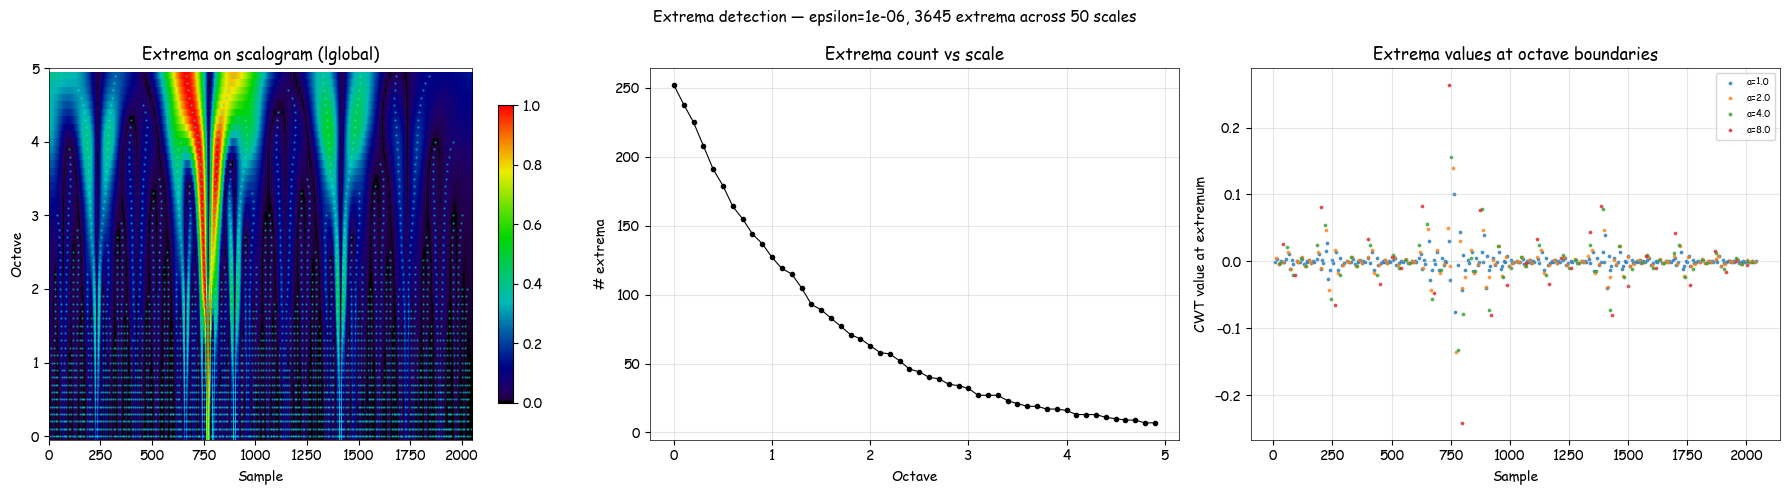


   Scale   Octave  # ext
--------------------------
    1.00    0.000    252
    2.00    1.000    127
    4.00    2.000     63
    8.00    3.000     32
   16.00    4.000     16


In [30]:
# LastWave ground truth — Step 3: Extrema detection on CWT
#
# DemoWTMM1DDevilStair does:
#   extrema w          (default epsilon=1e-6, interpolated)
#   chainmax w.extrep 1
#
# lw_compute_extrema runs ComputeExtrep on the global wtrans from the previous CWT.
# Then we extract extrema positions & values at each scale for visualization.

# ── Declare function signatures ──
lib.lw_compute_extrema.restype = ctypes.c_int
lib.lw_compute_extrema.argtypes = [ctypes.c_double]

lib.lw_get_extrema_count.restype = ctypes.c_int
lib.lw_get_extrema_count.argtypes = [ctypes.c_int, ctypes.c_int]

lib.lw_get_extrema_at_scale.restype = ctypes.c_int
lib.lw_get_extrema_at_scale.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.c_int,
]

lib.lw_get_n_oct.restype = ctypes.c_int
lib.lw_get_n_voice.restype = ctypes.c_int

# ── Compute extrema ──
epsilon = 1e-6  # LastWave default
nb_ext = lib.lw_compute_extrema(ctypes.c_double(epsilon))
assert nb_ext >= 0, f"lw_compute_extrema failed: {lib.lw_get_error()}"
print(f"Total extrema found: {nb_ext}")

# ── Extract extrema at every scale ──
ext_data = {}  # (octave, voice) -> (positions, values)
total = 0
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        count = lib.lw_get_extrema_count(o, v)
        if count <= 0:
            continue
        pos = np.zeros(count, dtype=np.float64)
        val = np.zeros(count, dtype=np.float64)
        got = lib.lw_get_extrema_at_scale(
            o, v,
            pos.ctypes.data_as(c_double_p),
            val.ctypes.data_as(c_double_p),
            count,
        )
        ext_data[(o, v)] = (pos[:got], val[:got])
        total += got

print(f"Extracted {total} extrema across {len(ext_data)} scales")

# ── Plot: extrema overlaid on scalogram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel 1: scalogram with extrema scatter (LastWave lglobal)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
# Overlay extrema
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    log2_a = log2_scales[scale_idx]
    axes[0].scatter(pos, np.full_like(pos, log2_a), s=0.3, c='cyan', alpha=0.5)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Octave')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('Extrema on scalogram (lglobal)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Panel 2: extrema count vs scale
ext_counts = np.zeros(n_scales, dtype=int)
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    ext_counts[scale_idx] = len(pos)
axes[1].plot(log2_scales, ext_counts, 'k.-', lw=0.8)
axes[1].set_xlabel('Octave')
axes[1].set_ylabel('# extrema')
axes[1].set_title('Extrema count vs scale')
axes[1].grid(True, alpha=0.3)

# Panel 3: extrema at a few selected scales
sel_scales = [(1, 0), (2, 0), (3, 0), (4, 0)]
for (o, v) in sel_scales:
    if (o, v) in ext_data:
        pos, val = ext_data[(o, v)]
        scale_idx = (o - 1) * n_voice + v
        axes[2].scatter(pos, val, s=3, label=f'a={scales[scale_idx]:.1f}', alpha=0.7)
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('CWT value at extremum')
axes[2].set_title('Extrema values at octave boundaries')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Extrema detection — epsilon={epsilon}, {total} extrema across {n_scales} scales', fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"\n{'Scale':>8} {'Octave':>8} {'# ext':>6}")
print('-' * 26)
for s in range(0, n_scales, n_voice):
    o = s // n_voice + 1
    v = s % n_voice
    c = ext_counts[s]
    print(f'{scales[s]:8.2f} {log2_scales[s]:8.3f} {c:6d}')

ChainDelete removed 0 unchained extrema
Chains remaining: 252
Extracted 252 chains, lengths: min=1, max=50, median=11


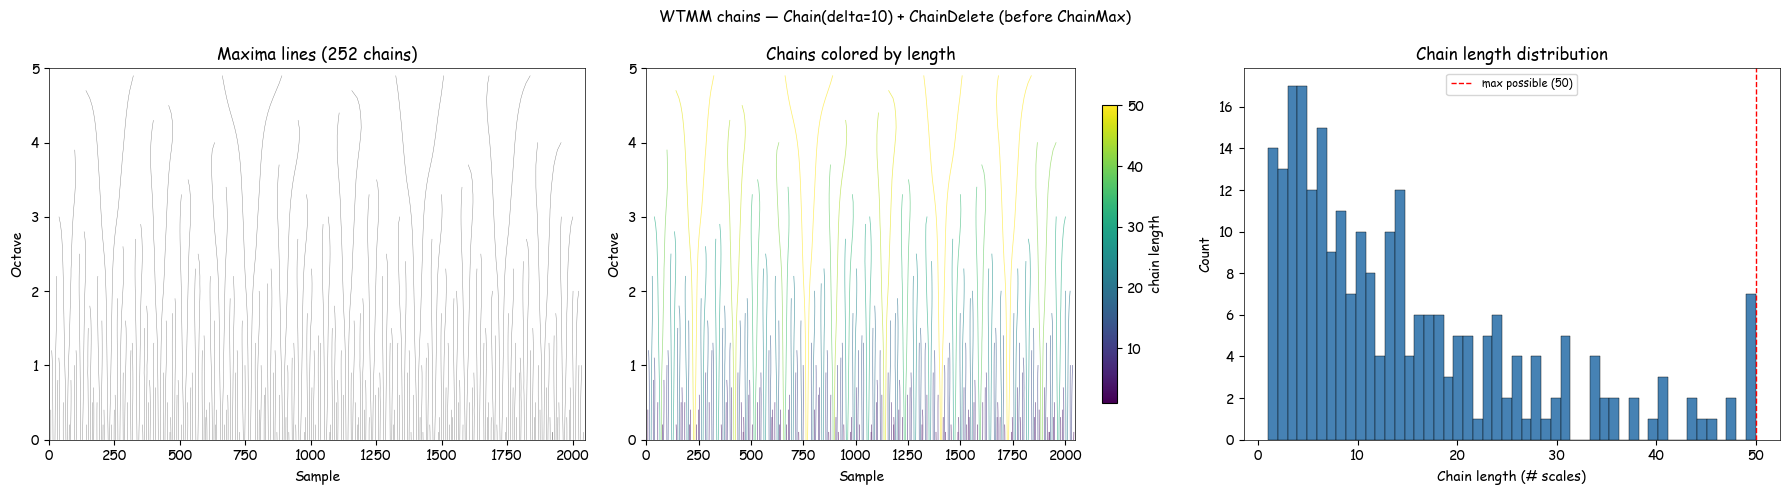

In [31]:
# LastWave ground truth — Step 3: Chain + ChainDelete + plot maxima lines
#
# Chain() builds linked lists via coarser/finer pointers.
# ChainDelete() prunes extrema not part of any chain.
# ChainMax is deferred to a later cell so we can compare before/after.

# ── Declare signatures ──
lib.lw_chain.restype = ctypes.c_int
lib.lw_chain.argtypes = [ctypes.c_double]

lib.lw_chain_delete.restype = ctypes.c_int
lib.lw_chain_delete.argtypes = []

lib.lw_chain_max.restype = ctypes.c_int
lib.lw_chain_max.argtypes = [ctypes.c_double]

lib.lw_get_num_chains.restype = ctypes.c_int
lib.lw_get_num_chains.argtypes = []

lib.lw_get_chain.restype = ctypes.c_int
lib.lw_get_chain.argtypes = [
    ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int), ctypes.c_int,
]

def extract_chains():
    """Extract all chains from the current extrep."""
    nc = lib.lw_get_num_chains()
    max_len = n_scales + 1
    result = []
    for ci in range(nc):
        abs_buf = np.zeros(max_len, dtype=np.float64)
        ord_buf = np.zeros(max_len, dtype=np.float64)
        scl_buf = np.zeros(max_len, dtype=np.int32)
        length = lib.lw_get_chain(
            ci,
            abs_buf.ctypes.data_as(c_double_p),
            ord_buf.ctypes.data_as(c_double_p),
            scl_buf.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
            max_len,
        )
        if length > 0:
            result.append({
                'x': abs_buf[:length].copy(),
                'val': ord_buf[:length].copy(),
                'scale_idx': scl_buf[:length].copy(),
                'log2_a': np.log2(a_min) + scl_buf[:length] / n_voice,
            })
    return result

# ── Build chains ──
ret = lib.lw_chain(ctypes.c_double(10.0))   # delta=10 (default)
assert ret == 0, f"lw_chain failed: {lib.lw_get_error()}"

deleted = lib.lw_chain_delete()
print(f"ChainDelete removed {deleted} unchained extrema")

n_chains = lib.lw_get_num_chains()
print(f"Chains remaining: {n_chains}")

# ── Extract BEFORE chainmax ──
chains = extract_chains()

print(f"Extracted {len(chains)} chains, lengths: min={min(len(c['x']) for c in chains)}, "
      f"max={max(len(c['x']) for c in chains)}, "
      f"median={np.median([len(c['x']) for c in chains]):.0f}")

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes[:2]:
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, n_oct)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Octave')
    ax.set_yticks(range(0, n_oct + 1))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

for ch in chains:
    axes[0].plot(ch['x'], ch['log2_a'], 'k-', lw=0.3, alpha=0.5)
axes[0].set_title(f'Maxima lines ({len(chains)} chains)')

lengths = np.array([len(c['x']) for c in chains])
norm = plt.Normalize(lengths.min(), lengths.max())
cmap = plt.cm.viridis
for ch in chains:
    color = cmap(norm(len(ch['x'])))
    axes[1].plot(ch['x'], ch['log2_a'], '-', color=color, lw=0.5, alpha=0.7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=axes[1], label='chain length', shrink=0.8)
axes[1].set_title('Chains colored by length')

axes[2].hist(lengths, bins=50, color='steelblue', edgecolor='k', lw=0.3)
axes[2].set_xlabel('Chain length (# scales)')
axes[2].set_ylabel('Count')
axes[2].set_title('Chain length distribution')
axes[2].axvline(n_scales, color='r', ls='--', lw=1, label=f'max possible ({n_scales})')
axes[2].legend(fontsize=8)

plt.suptitle(f"WTMM chains — Chain(delta=10) + ChainDelete (before ChainMax)", fontsize=11)
plt.tight_layout()
plt.show()

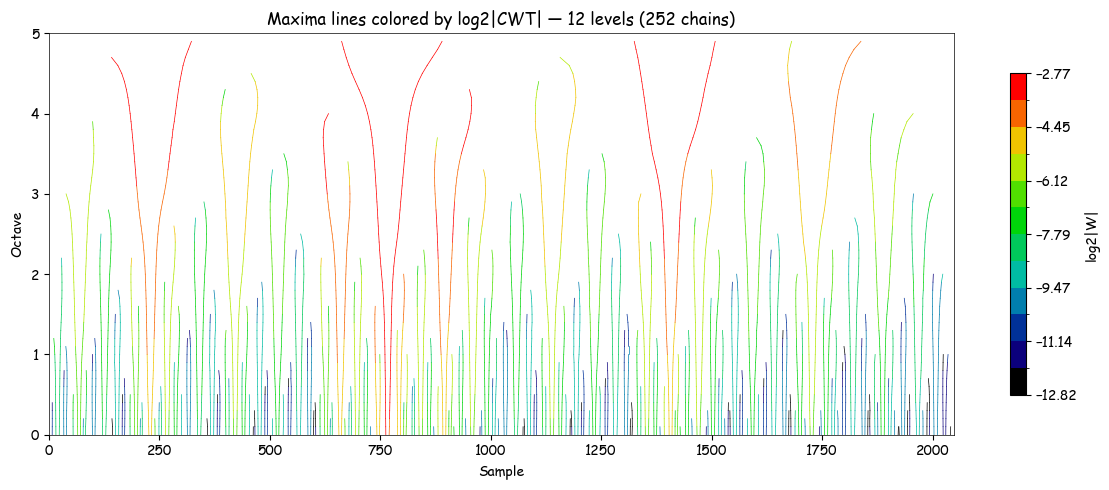

In [32]:
# Chains colored by log2|ordinate| (lastwave colormap, discretized)
N_COLORS = 12  # ← change this to set number of discrete color bins

fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains])
vmin, vmax = np.percentile(all_log2_vals, [2, 98])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W|', shrink=0.8)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines colored by log2|CWT| — {N_COLORS} levels ({len(chains)} chains)')
plt.tight_layout(); plt.show()

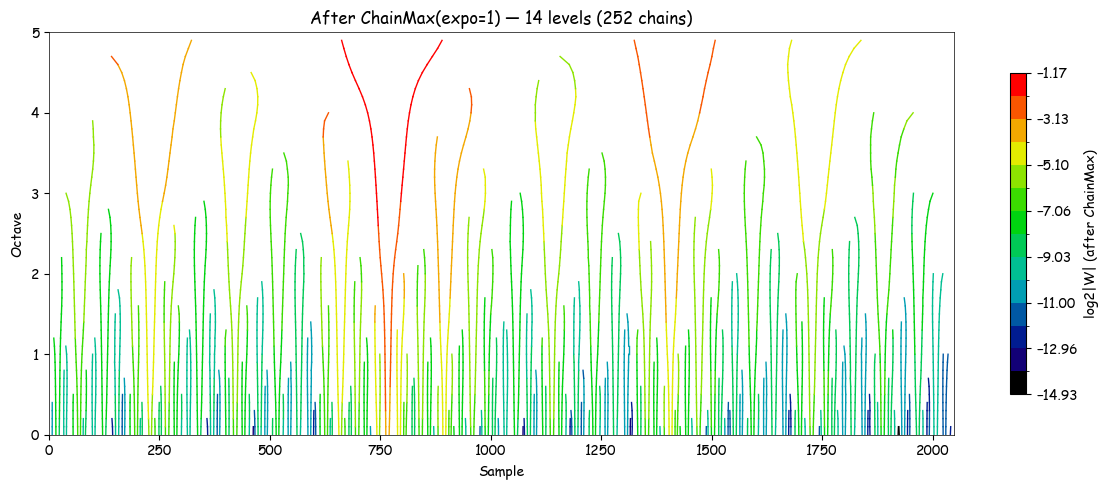

In [33]:
# Chains after ChainMax(expo=1) — colored by log2|ordinate| (lastwave colormap)
# ChainMax replaces each ordinate with the scale-adaptive max along the chain.
# Compare with cell 4 to see the difference.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14

ret = lib.lw_chain_max(ctypes.c_double(1.0))
assert ret == 0, f"lw_chain_max failed: {lib.lw_get_error()}"

chains_cm = extract_chains()

fig, ax = plt.subplots(figsize=(12, 5))
all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains_cm])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains_cm:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W| (after ChainMax)', shrink=0.8)

# Tight margins: bottom and sides flush, keep top gap
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — {N_COLORS} levels ({len(chains_cm)} chains)')

# Thin frames
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'  # reset after

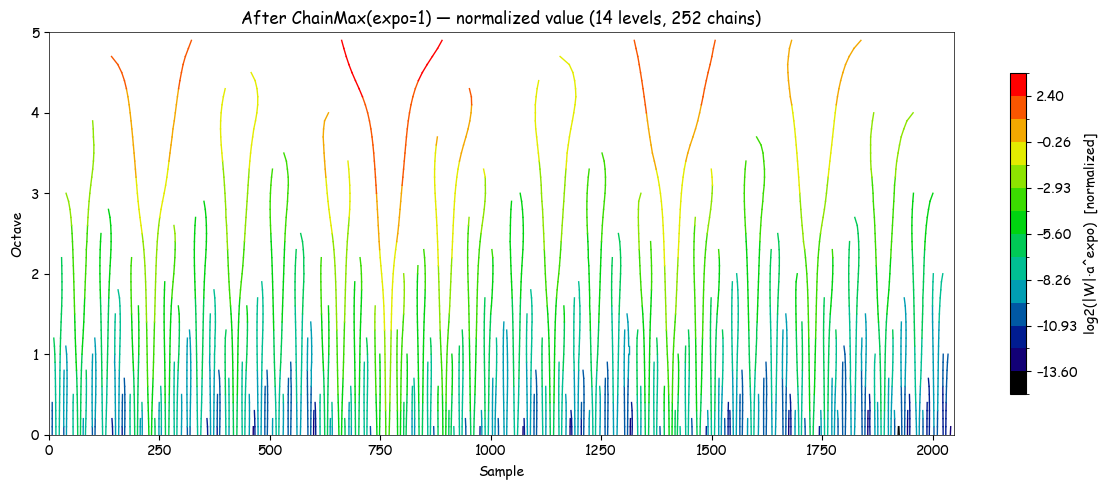

In [34]:
# Chains after ChainMax(expo=1) — colored by NORMALIZED value log2(|W|·a^expo)
# ChainMax guarantees monotonicity of the normalized value |W|·a^expo along each chain
# (non-increasing from fine→coarse). If ChainMax worked, each chain should appear
# as a single color or transition smoothly from warm (fine) to cool (coarse).

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14
expo = 1.0

fig, ax = plt.subplots(figsize=(12, 5))

# Compute normalized values: |ordinate| * a^expo = |ordinate| * a_min * 2^(expo * scale_idx / n_voice)
all_norm_vals = []
for ch in chains_cm:
    norm_val = np.log2(np.abs(ch['val']) + 1e-300) + expo * ch['scale_idx'] / n_voice + np.log2(a_min)
    all_norm_vals.append(norm_val)

all_norm_concat = np.concatenate(all_norm_vals)
vmin, vmax = np.percentile(all_norm_concat, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

for ch, nv in zip(chains_cm, all_norm_vals):
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(nv[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2(|W|·a^expo)  [normalized]', shrink=0.8)

ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — normalized value ({N_COLORS} levels, {len(chains_cm)} chains)')

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

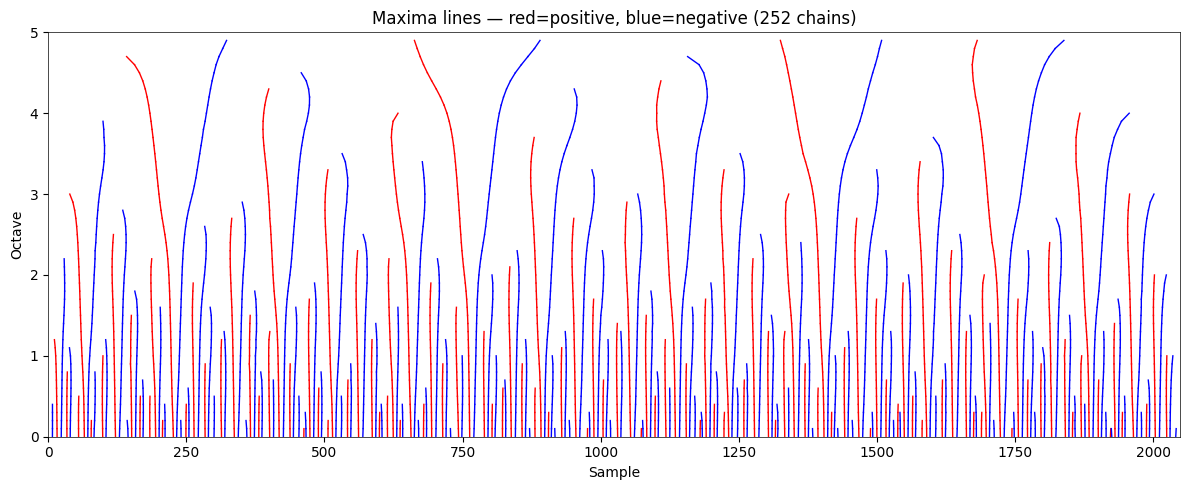

In [35]:
# Chains colored by sign: positive (red) / negative (blue)
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
for ch in chains:
    sign = np.sign(ch['val'])
    for j in range(len(ch['x']) - 1):
        c = 'red' if sign[j] > 0 else 'blue'
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=c, lw=1, alpha=1)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines — red=positive, blue=negative ({len(chains)} chains)')
plt.tight_layout(); plt.show()

PF computed: 50 scales done, pf_size=50, n_q=12
Spectra computed via LastWave LineFitSig over [1.0, 4.0]


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_31705/2660045118.py:105: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import brentq


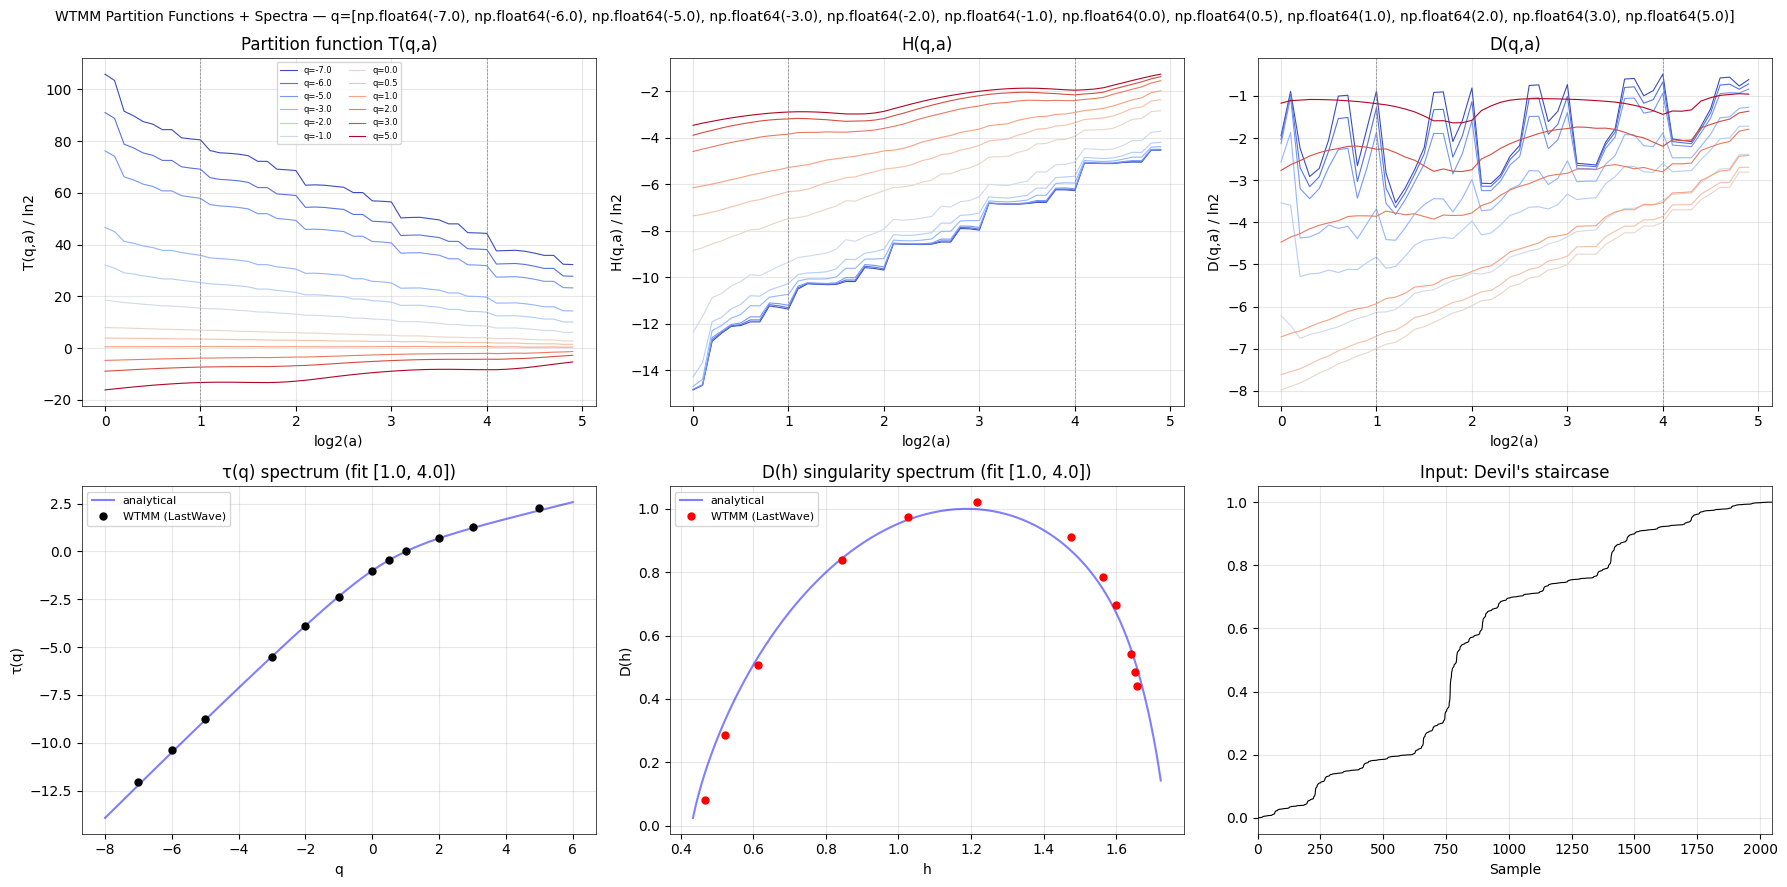


     q     tau(q)       ±σ       h(q)       ±σ       D(q)       ±σ
--------------------------------------------------------------------
  -7.0   -12.0466   0.2719     1.6581   0.0600     0.4395   0.1773
  -6.0   -10.3916   0.2159     1.6512   0.0574     0.4843   0.1563
  -5.0    -8.7454   0.1638     1.6405   0.0532     0.5431   0.1282
  -3.0    -5.4995   0.0786     1.6007   0.0388     0.6975   0.0576
  -2.0    -3.9151   0.0476     1.5648   0.0308     0.7856   0.0289
  -1.0    -2.3863   0.0235     1.4762   0.0239     0.9101   0.0128
   0.0    -1.0212   0.0094     1.2175   0.0127     1.0212   0.0094
   0.5    -0.4597   0.0071     1.0261   0.0095     0.9728   0.0094
   1.0     0.0066   0.0076     0.8444   0.0122     0.8377   0.0114
   2.0     0.7202   0.0239     0.6142   0.0280     0.5082   0.0344
   3.0     1.2812   0.0558     0.5220   0.0356     0.2849   0.0527
   5.0     2.2566   0.1230     0.4674   0.0310     0.0804   0.0360


In [36]:
# LastWave ground truth — Step 4: Partition functions + tau(q) + D(h) singularity spectrum
#
# DemoWTMM1DDevilStair:
#   qlist = {-7 -6 -5 -3 -2 -1 0 0.5 1 2 3 5}
#   pft = [pf wtmm w.extrep qlist]
#   disp {0w [tauqSpectrum pf 1 4] [singSpectrum pf 1 4]}
#
# tauqSpectrum/singSpectrum do linear regression of T(q,a), H(q,a), D(q,a)
# vs log2(a) over [log2aMin, log2aMax] = [1, 4].
# PF access functions return natural log; convert to log2 by dividing by ln(2).

# ── Declare signatures ──
lib.lw_compute_pf.restype = ctypes.c_int
lib.lw_compute_pf.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.c_int]

lib.lw_get_pf_size.restype = ctypes.c_int
lib.lw_get_pf_size.argtypes = []

lib.lw_get_pf_tq.restype = ctypes.c_int
lib.lw_get_pf_tq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_hq.restype = ctypes.c_int
lib.lw_get_pf_hq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_dq.restype = ctypes.c_int
lib.lw_get_pf_dq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

# ── Compute partition functions ──
q_list = np.array([-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5], dtype=np.float64)
n_q = len(q_list)

n_scales_done = lib.lw_compute_pf(q_list.ctypes.data_as(c_double_p), n_q)
assert n_scales_done > 0, f"lw_compute_pf failed: {lib.lw_get_error()}"

pf_size = lib.lw_get_pf_size()
print(f"PF computed: {n_scales_done} scales done, pf_size={pf_size}, n_q={n_q}")

# ── Extract T(q,a), H(q,a), D(q,a) for all q ──
# Mode: PFEXTENSIVE=0, PFINTENSIVE=1
# PF x-axis: x0 = log2(a_min), dx = 1/n_voice
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
ln2 = np.log(2.0)

tq_all = {}  # q -> T(q,a) array in log2 units
hq_all = {}  # q -> H(q,a)
dq_all = {}  # q -> D(q,a)

for iq, q in enumerate(q_list):
    buf = np.zeros(pf_size, dtype=np.float64)

    ret = lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    tq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_hq(iq, 0, buf.ctypes.data_as(c_double_p))
    hq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_dq(iq, 0, buf.ctypes.data_as(c_double_p))
    dq_all[q] = buf.copy() / ln2 if ret > 0 else None

# ── Spectra via LastWave's own LineFitSig (replicates singSpectrum/tauqSpectrum) ──
log2a_min_fit, log2a_max_fit = 1.0, 4.0

lib.lw_compute_tauq_spectrum.restype = ctypes.c_int
lib.lw_compute_tauq_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]
lib.lw_compute_sing_spectrum.restype = ctypes.c_int
lib.lw_compute_sing_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]

tau_q = np.zeros(n_q, dtype=np.float64)
tau_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_tauq_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    tau_q.ctypes.data_as(c_double_p), tau_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_tauq_spectrum failed: {lib.lw_get_error()}"

h_q = np.zeros(n_q, dtype=np.float64)
h_sigma = np.zeros(n_q, dtype=np.float64)
d_q = np.zeros(n_q, dtype=np.float64)
d_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_sing_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    h_q.ctypes.data_as(c_double_p), h_sigma.ctypes.data_as(c_double_p),
    d_q.ctypes.data_as(c_double_p), d_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_sing_spectrum failed: {lib.lw_get_error()}"

print(f"Spectra computed via LastWave LineFitSig over [{log2a_min_fit}, {log2a_max_fit}]")


# ── Analytical tau(q) and D(h) for the inhomogeneous Cantor measure ──
# For a multinomial measure with parts (r_i, p_i), tau(q) satisfies:
#   sum_i  p_i^q * r_i^(-tau) = 1
# Solved numerically for each q. Then h(q) = tau'(q) and D(h) = q*h - tau.
from scipy.optimize import brentq

r_cantor = np.array([0.3, 0.2, 0.5])
p_cantor = np.array([0.2, 0.5, 0.3])

from wtmm.signals import tau_equation

q_fine = np.linspace(-8, 6, 500)
tau_analytical = np.zeros_like(q_fine)
for i, q in enumerate(q_fine):
    tau_analytical[i] = brentq(tau_equation, -20, 20, args=(q, r_cantor, p_cantor))

# h(q) = d(tau)/dq via finite differences
h_analytical = np.gradient(tau_analytical, q_fine)
# D(h) = q*h - tau  (Legendre transform)
d_analytical = q_fine * h_analytical - tau_analytical

# ── Plot ──
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel (0,0): T(q,a) vs log2(a) for selected q
colors_q = plt.cm.coolwarm(np.linspace(0, 1, n_q))
for iq, q in enumerate(q_list):
    if tq_all[q] is not None:
        axes[0, 0].plot(log2_a_pf, tq_all[q], '-', color=colors_q[iq], lw=0.8, label=f'q={q}')
axes[0, 0].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].set_xlabel('log2(a)')
axes[0, 0].set_ylabel('T(q,a) / ln2')
axes[0, 0].set_title('Partition function T(q,a)')
axes[0, 0].legend(fontsize=6, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# Panel (0,1): H(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if hq_all[q] is not None:
        axes[0, 1].plot(log2_a_pf, hq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 1].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].set_xlabel('log2(a)')
axes[0, 1].set_ylabel('H(q,a) / ln2')
axes[0, 1].set_title('H(q,a)')
axes[0, 1].grid(True, alpha=0.3)

# Panel (0,2): D(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if dq_all[q] is not None:
        axes[0, 2].plot(log2_a_pf, dq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 2].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].set_xlabel('log2(a)')
axes[0, 2].set_ylabel('D(q,a) / ln2')
axes[0, 2].set_title('D(q,a)')
axes[0, 2].grid(True, alpha=0.3)

# Panel (1,0): tau(q) spectrum
axes[1, 0].plot(q_fine, tau_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 0].plot(q_list, tau_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 0].set_xlabel('q')
axes[1, 0].set_ylabel('\u03c4(q)')
axes[1, 0].set_title(f'\u03c4(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Panel (1,1): D(h) singularity spectrum
axes[1, 1].plot(h_analytical, d_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
sort_idx = np.argsort(h_q)
axes[1, 1].plot(h_q[sort_idx], d_q[sort_idx], 'ro', markersize=5, label='WTMM (LastWave)')
axes[1, 1].set_xlabel('h')
axes[1, 1].set_ylabel('D(h)')
axes[1, 1].set_title(f'D(h) singularity spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# Panel (1,2): Devil's staircase for reference
axes[1, 2].plot(lw_staircase, 'k-', lw=0.8)
axes[1, 2].set_xlim(0, SIZE)
axes[1, 2].set_title("Input: Devil's staircase")
axes[1, 2].set_xlabel('Sample')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"WTMM Partition Functions + Spectra — q={list(q_list)}", fontsize=10)
plt.tight_layout()
plt.show()

# ── Summary ──
print(f"\n{'q':>6} {'tau(q)':>10} {'±σ':>8} {'h(q)':>10} {'±σ':>8} {'D(q)':>10} {'±σ':>8}")
print('-' * 68)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} {tau_q[iq]:10.4f} {tau_sigma[iq]:8.4f} {h_q[iq]:10.4f} {h_sigma[iq]:8.4f} {d_q[iq]:10.4f} {d_sigma[iq]:8.4f}')

# Faithful WTMM Implementation with GPU Acceleration

A Python reimplementation of LastWave's WTMM (Wavelet Transform Modulus Maxima) algorithm
for multifractal analysis. Faithfully matches LastWave's `CWtd()`, `extrema`, `chain`,
`chainmax`, and `pf wtmm` pipeline.

**GPU**: PyTorch MPS on Apple Silicon M2 Max

In [45]:
# Cell 0: Imports and device setup
#
# Fix duplicate libomp crash (torch + numba both link OpenMP on macOS)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

# Device setup — prefer MPS but only if it supports float64 conv1d.
# Float32 introduces quantization noise that creates spurious extrema
# ("cloud of points" bug around each true maximum).
device = torch.device('cpu')  # safe default
cwt_device = torch.device('cpu')  # device used specifically for CWT conv1d

if torch.backends.mps.is_available():
    device = torch.device('mps')
    # Test if MPS supports float64 conv1d (varies by PyTorch version)
    try:
        _test_sig = torch.randn(1, 1, 8, dtype=torch.float64, device=device)
        _test_flt = torch.randn(1, 1, 3, dtype=torch.float64, device=device)
        torch.nn.functional.conv1d(_test_sig, _test_flt)
        cwt_device = device
        print(f'Using MPS (Apple Silicon GPU) — float64 conv1d supported')
    except RuntimeError:
        cwt_device = torch.device('cpu')
        print(f'MPS available but float64 conv1d unsupported — CWT uses CPU (float64)')
    finally:
        del _test_sig, _test_flt
else:
    print(f'MPS not available, using CPU')

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, CWT device: {cwt_device}, dtype: float64')


NameError: name '_test_sig' is not defined

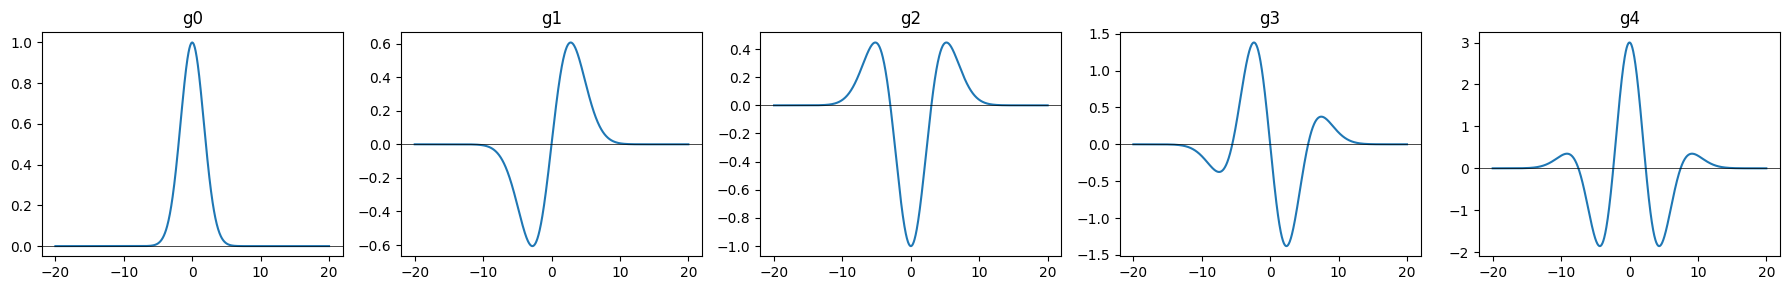

In [46]:
from wtmm.wavelets import WAVELETS, wavelet_direct, wavelet_support

# Quick test: plot g2 at scale a=1
x_test = np.linspace(-20, 20, 1000)
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, name in enumerate(['g0', 'g1', 'g2', 'g3', 'g4']):
    axes[i].plot(x_test, wavelet_direct(x_test, 1.0, name))
    axes[i].set_title(name)
    axes[i].axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 2: CWT engine (faithful to LastWave's cwt1d.c CWtd())
#
# Scale computation: factor = 2^(1/n_voice), scales = a_min * factor^i
# Filter: sample wavelet at integer points, reversed (LastWave convention)
# Border: mirror padding (reflect)
# Normalization: multiply by a^expo after convolution
#
# Precision: all computation in float64. If MPS supports float64, conv1d runs
# on GPU; otherwise it runs on CPU. Float32 creates quantization noise that
# produces spurious extrema ("cloud of points" around each true maximum).

from wtmm.cwt import compute_scales, cwtd, cwtd_batched

print('CWT engine defined. Use cwtd() for faithful per-scale, cwtd_batched() for optimized.')
print(f'CWT device: {cwt_device}, dtype: float64')

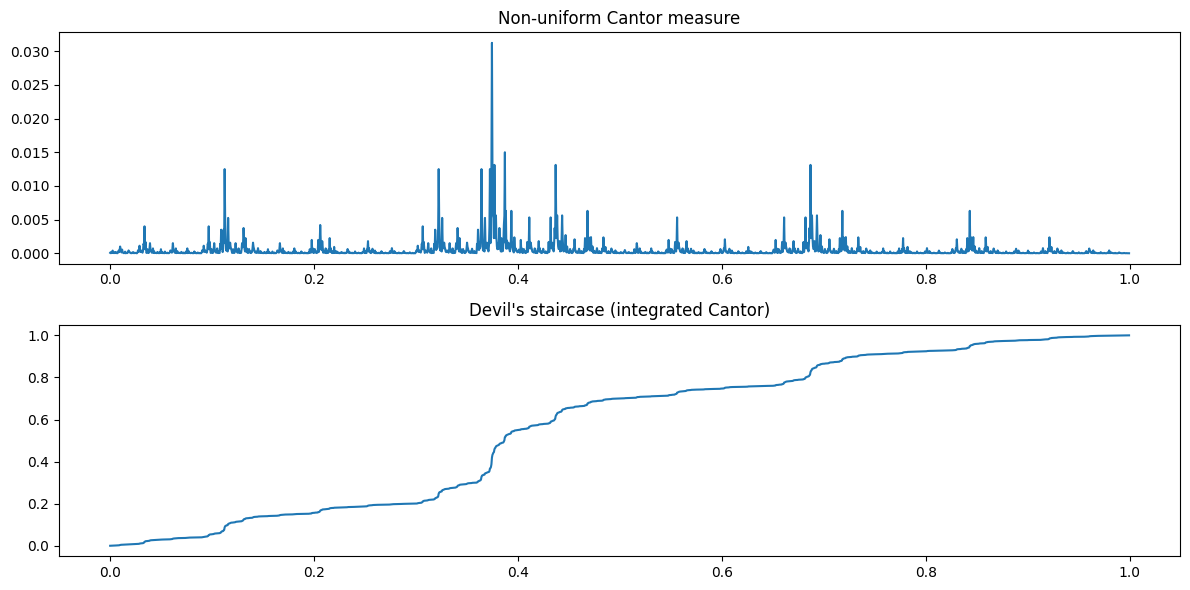

Signal size: 2048, dx: 0.00048828125
Staircase range: [0.0001, 1.0000]


In [ ]:
# Cell 3: Devil's staircase test signal
# Matching LastWave's UCantor() from signal_create.c
#
# DemoWTMM1DDevilStair uses:
#   ucantor 0w 2048 0.3 0.2 0.2 0.5 0.5 0.3
# which means r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3]
# Then integrates: 0w = prim(0w)

from wtmm.signals import ucantor

# Generate devil's staircase: ucantor then prim (cumulative sum)
# DemoWTMM1DDevilStair: ucantor 0w size 0.3 0.2 0.2 0.5 0.5 0.3
# Command parsing: signal size r0 p0 r1 p1 r2 p2
# So r = [0.3, 0.2, 0.5], p = [0.2, 0.5, 0.3]
# nFlip defaults to 0, but C_UCantor does nFlip-- so nFlip = -1 (no flip)

SIZE = 2048
cantor_measure, dx = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)

# prim = cumulative sum (matching LastWave's prim())
devil_staircase = np.cumsum(cantor_measure)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
t_axis = np.arange(SIZE) * dx
ax1.plot(t_axis, cantor_measure)
ax1.set_title('Non-uniform Cantor measure')
ax2.plot(t_axis, devil_staircase)
ax2.set_title("Devil's staircase (integrated Cantor)")
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}, dx: {dx}')
print(f'Staircase range: [{devil_staircase.min():.4f}, {devil_staircase.max():.4f}]')

In [ ]:
# Cell 4: CWT + visualization on devil's staircase
# DemoWTMM1DDevilStair: cwtd w 1.0 5 10 'g2' -b 'mir'
# Default expo = -1

t0 = time.time()
coeffs, scales, valid_ranges = cwtd_batched(devil_staircase, a_min=1.0, n_oct=5, n_voice=10,
                                             wavelet_name='g2', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram — LastWave lglobal normalization (no log)
fig, ax = plt.subplots(figsize=(14, 6))
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode='lglobal')
ax.set_title('|CWT| lglobal (g2 wavelet, devil staircase)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()

In [38]:
# Cell 5: Extrema detection with Numba (faithful to ext_compute.c)
#
# Flat-array representation for Numba compatibility:
#   extrep_abs[scale] = 1D array of abscissa values

from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=5, n_voice=10, a_min=1.0,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
for sidx in [0, 10, 20, 30, 40, 49]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

NameError: name 'valid_ranges' is not defined

In [39]:
# Cell 6: Chaining with Numba (faithful to ext_chain.c)
#
# Chain links stored as integer index arrays:
#   coarser_links[scale][i] = index into extrep_*[scale+1], or -1

from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=5, n_voice=10)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, 5 * 10)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=5, n_voice=10)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=5, n_voice=10, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

NameError: name 'extrep_abs' is not defined

In [40]:
# Cell 7: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, 5 * 10)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, *_rest in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, *_rest in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))

# Draw deleted chains first (background, grey)
for pos, sv, sign, *_rest in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Draw surviving chains on top
for pos, sv, sign, *_rest in post_del_chains:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — {len(post_del_chains)} surviving (color), {len(deleted_chains)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

NameError: name 'extrep_abs' is not defined

In [41]:
# Cell 8: Partition function (faithful to pf_lib.c PFComputeOneScaleFLOAT)
#
# LastWave stores 7 per-scale arrays per q value:
#   sTq              = sum |T_i|^q                       (the partition function Z(q,a))
#   sTqLogT          = sum |T_i|^q * ln|T_i|             (for h(q) derivative)
#   logSTq           = ln(sTq / N_nonzero)               (intensive-mode log partition function)
#   sTqLogT_sTq      = sTqLogT / sTq                     (= <ln|T|>_q, used for h(q,a))
#   log2STq          = logSTq^2                           (for variance of tau across realizations)
#   sTqLogT_sTq2     = (sTqLogT/sTq)^2                   (for variance of h across realizations)
#   logSTqSTqLogT_sTq = logSTq * sTqLogT_sTq             (cross-term for variance of D)
#
# Access functions (extensive mode, single signal):

from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D, pf_copy

# Compute partition function
q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=5, n_voice=10, a_min=1.0, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a) — this is what LastWave's "pf get t" returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')

NameError: name 'extrep_ord' is not defined

In [42]:
# Cell 9: tau(q), h(q), D(h) spectrum
#
# Linear regression of T(q,a), H(q,a), D(q,a) vs log2(a) over selected scale range.
# ALL spectra are obtained from the SLOPE of the regression.
# Matches LastWave's tauqSpectrum and singSpectrum scripts:
#   tauqSpectrum: tau(q) = slope of T(q,a) vs log2(a)
#   singSpectrum: h(q) = slope of H(q,a) vs log2(a)
#                 D(q) = slope of D(q,a) vs log2(a)

from wtmm.spectra import compute_spectra, theoretical_devil_staircase

# Compute spectra
# DemoWTMM1DDevilStair: tauqSpectrum pf 1 4 and singSpectrum pf 1 4
spectra = compute_spectra(pf, log2_a_min=1.0, log2_a_max=4.0)

# Theoretical values — use expo=-1 to match our CWT normalization
q_fine = np.linspace(-7, 5, 200)
tau_theory, h_theory, D_theory = theoretical_devil_staircase(
    q_fine, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

tau_theory_q, h_theory_q, D_theory_q = theoretical_devil_staircase(
    spectra['q_list'], r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. tau(q)
ax = axes[0]
ax.plot(q_fine, tau_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q) comparison
ax = axes[1]
ax.plot(q_fine, h_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) = slope of H(q,a) vs log2(a)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. D(h) singularity spectrum
ax = axes[2]
ax.plot(h_theory, D_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

# Print comparison
print(f'\nTheoretical: expo={-1.0}, so tau_WTMM = tau_measure (integration + 1/a cancel)')
print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
print('\nq\t tau_WTMM\t tau_theory\t diff\t\t h_WTMM\t\t h_theory')
for i, q in enumerate(spectra['q_list']):
    print(f'{q:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
          f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')

NameError: name 'pf' is not defined

Loaded 5265519 samples from xmr1.10min.gz
Time range: 1980.0821 to 2025.8504 (decimal year)
dt = 0.000002 year (1.0 min)
Displacement range: 5.088 to 750.884 mm
Using segment of 65536 samples starting at index 1687552
Segment time: 2018.6844 to 2018.8090
Segment value range: 644.269 to 650.348 mm


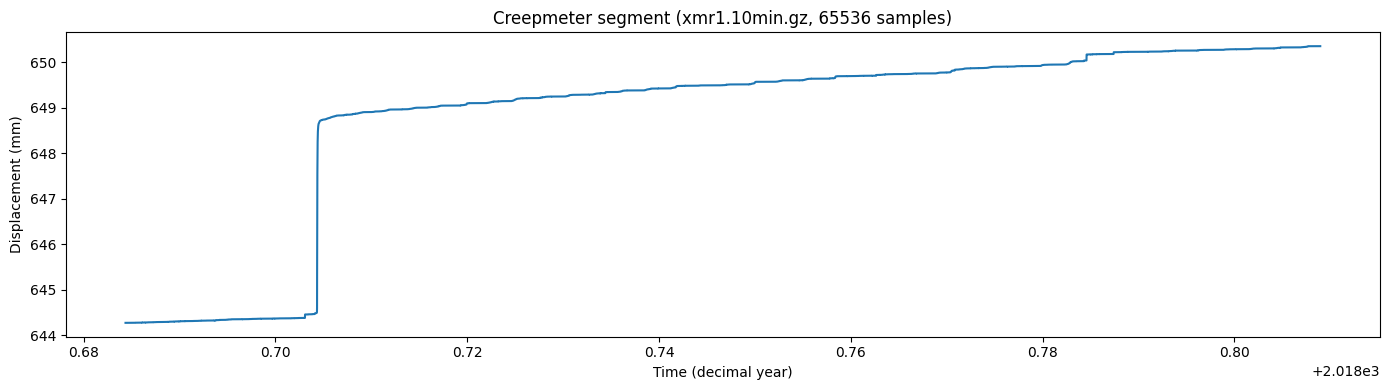

In [43]:
# Cell 10: Load creepmeter data (XMR1) and select clean segment
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.
#
# File format: year  day_of_year  displacement(mm)  uncertainty

import os
import gzip

# Load XMR1 data
xmr_path = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/gz/xmr1.10min.gz'
if not os.path.exists(xmr_path):
    xmr_path = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/xmr1.10min.gz'

if os.path.exists(xmr_path):
    with gzip.open(xmr_path, 'rt') as f:
        lines = f.readlines()
    
    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            try:
                year = float(parts[0])
                doy = float(parts[1])
                disp = float(parts[2])
                if disp != -9999:
                    # Convert to decimal year
                    t_val = year + doy / 365.25
                    data.append((t_val, disp))
            except ValueError:
                continue
    
    data = np.array(data)
    t_creep = data[:, 0]
    x_creep = data[:, 1]
    dt_creep = np.median(np.diff(t_creep))
    
    print(f'Loaded {len(x_creep)} samples from {os.path.basename(xmr_path)}')
    print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
    print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
    print(f'Displacement range: {x_creep.min():.3f} to {x_creep.max():.3f} mm')
    
    # Take a clean segment (no gaps)
    seg_len = min(65536, len(x_creep))
    for start in range(0, len(x_creep) - seg_len, seg_len // 4):
        segment_c = x_creep[start:start + seg_len]
        t_seg_c = t_creep[start:start + seg_len]
        gaps = np.diff(t_seg_c)
        if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
            break
    
    # No detrending — just use the raw displacement signal
    segment_c = segment_c.copy()
    print(f'Using segment of {seg_len} samples starting at index {start}')
    print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
    print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} mm')
    
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t_seg_c, segment_c)
    ax.set_xlabel('Time (decimal year)')
    ax.set_ylabel('Displacement (mm)')
    ax.set_title(f'Creepmeter segment ({os.path.basename(xmr_path)}, {seg_len} samples)')
    plt.tight_layout()
    plt.show()
else:
    print(f'Creepmeter data not found at {xmr_path}')
    creep_dir = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/'
    if os.path.isdir(creep_dir):
        files = [f for f in os.listdir(creep_dir) if 'xmr' in f.lower() or 'xhr' in f.lower()]
        print(f'Available files: {files[:10]}')

In [44]:
# Cell 11: CWT on creepmeter data + scalogram

n_oct_c, n_voice_c = 5, 10

t0 = time.time()
coeffs_c, scales_c, valid_ranges_c = cwtd_batched(segment_c, a_min=1.0, n_oct=n_oct_c,
                                                    n_voice=n_voice_c, wavelet_name='g2', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs_c.shape}, Scales: {len(scales_c)} ({scales_c[0]:.2f} to {scales_c[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges_c[0]}, coarsest: {valid_ranges_c[-1]}')

# Scalogram — log2 of modulus
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(segment_c)
ax.set_title('Creepmeter signal (detrended)')
ax.set_xlabel('Sample')

ax = axes[1]
im = scalogram_lastwave(coeffs_c, scales=scales_c, ax=ax,
                        norm_mode='lglobal')
ax.set_xlabel('Sample')
ax.set_title('|CWT| lglobal (g2 wavelet)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')

plt.tight_layout()
plt.show()

NameError: name 'cwtd_batched' is not defined

In [ ]:
# Cell 12: Extrema detection on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
ea_c, eo_c, ei_c = compute_extrep(coeffs_c, scales_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                   a_min=1.0, valid_ranges=valid_ranges_c,
                                   dx=1.0, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t0:.3f}s')
# Use actual scale count instead of hardcoded indices
sample_indices = [0, n_scales_c // 5, 2 * n_scales_c // 5, 3 * n_scales_c // 5, 4 * n_scales_c // 5, n_scales_c - 1]
for sidx in sample_indices:
    print(f'  Scale {sidx} (a={scales_c[sidx]:.2f}): {len(ea_c[sidx])} extrema')

# Extrema representation plot — vectorized scatter for speed
all_pos = []
all_log2s = []
all_signs = []
for sidx in range(len(ea_c)):
    n = len(ea_c[sidx])
    if n == 0:
        continue
    all_pos.append(ea_c[sidx])
    all_log2s.append(np.full(n, np.log2(scales_c[sidx])))
    all_signs.append(eo_c[sidx] > 0)

all_pos = np.concatenate(all_pos)
all_log2s = np.concatenate(all_log2s)
all_signs = np.concatenate(all_signs)

fig, ax = plt.subplots(figsize=(14, 6))
pos_mask = all_signs
ax.scatter(all_pos[pos_mask], all_log2s[pos_mask], c='red', s=0.1, linewidths=0)
ax.scatter(all_pos[~pos_mask], all_log2s[~pos_mask], c='blue', s=0.1, linewidths=0)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title('Extrema representation — creepmeter (red=positive, blue=negative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13: Chaining + ChainMax on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
cl_c, fl_c = chain_all(ea_c, eo_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs_c, pre_del_ord_c, pre_del_cl_c = save_chain_state(ea_c, eo_c, cl_c)
pre_del_chains_c = trace_chains(pre_del_abs_c, pre_del_ord_c, pre_del_cl_c, scales_c, n_scales_c)

nb_del = chain_delete_all(ea_c, eo_c, ei_c, cl_c, fl_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

chain_max_wrapper(eo_c, cl_c, n_oct=n_oct_c, n_voice=n_voice_c, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')

remaining = sum(len(a) for a in ea_c)
print(f'Remaining extrema: {remaining}')

# Surviving vs deleted chains
post_del_chains_c = trace_chains(ea_c, eo_c, cl_c, scales_c, n_scales_c)

surviving_starts_c = set()
for pos, sv, sign, *_rest in post_del_chains_c:
    surviving_starts_c.add((pos[0], sign))

deleted_chains_c = []
for pos, sv, sign, *_rest in pre_del_chains_c:
    if (pos[0], sign) not in surviving_starts_c:
        deleted_chains_c.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains_c)}')
print(f'Surviving chains: {len(post_del_chains_c)}')
print(f'Deleted chains: {len(deleted_chains_c)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))

for pos, sv, sign, *_rest in deleted_chains_c:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

for pos, sv, sign, *_rest in post_del_chains_c:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — creepmeter: {len(post_del_chains_c)} surviving (color), {len(deleted_chains_c)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 14: Partition functions on creepmeter data — T(q,a), H(q,a), D(q,a) vs log2(a)

q_list_c = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf_c = compute_partition_function(eo_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                  a_min=1.0, q_list=q_list_c)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf_c["index_max"]}')

# Plot T(q,a), H(q,a), D(q,a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
log2_ac = pf_c['log2_a']
valid_c = slice(0, pf_c['index_max'] + 1)
colors_c = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_c)))

ax = axes[0]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_T(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

ax = axes[1]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_H(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

ax = axes[2]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_D(pf_c, i, q)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')
print('Inspect these for linear scaling — adjust range if needed before next cell.')

In [ ]:
# Cell 15: tau(q), h(q), D(h) spectra for creepmeter data
# Adjust log2_a_min and log2_a_max based on visual inspection of Cell 14

spectra_c = compute_spectra(pf_c, log2_a_min=1.0, log2_a_max=4.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'ro-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'ro-', markersize=6)
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum — creepmeter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCreepmeter WTMM multifractal analysis:')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_c['q_list']):
    print(f'{q:5.1f}\t {spectra_c["tau_q"][i]:8.4f}\t {spectra_c["h_q"][i]:8.4f}\t {spectra_c["D_q"][i]:8.4f}')

In [ ]:
# Cell 16: Decimate creepmeter to hourly — 6 phase-shifted sub-signals
#
# 10-min sampling → every 6th sample = 1-hour sampling.
# Offsets 0..5 give 6 independent hourly series (like 6 "realizations").
# This is analogous to DemoWTMM1DDevilStair's 50 random realizations,
# except our "realizations" are phase offsets of the same physical process.

DECIM = 6  # decimation factor (10min × 6 = 60min = 1 hour)

# Build 6 hourly sub-signals
hourly_signals = []
for offset in range(DECIM):
    sub = segment_c[offset::DECIM].copy()
    hourly_signals.append(sub)
    
min_len = min(len(s) for s in hourly_signals)
print(f'Original signal: {len(segment_c)} samples at 10-min')
print(f'Decimated: {DECIM} sub-signals of {min_len} samples at 1-hour')
print(f'  (duration: {min_len / 24:.1f} days = {min_len / 24 / 365.25:.2f} years)')

# Plot all 6 overlaid
fig, ax = plt.subplots(figsize=(14, 4))
for offset in range(DECIM):
    t_hr = np.arange(len(hourly_signals[offset])) / 24  # days
    ax.plot(t_hr, hourly_signals[offset], alpha=0.6, linewidth=0.5,
            label=f'offset {offset}')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Displacement (mm)')
ax.set_title(f'6 hourly sub-signals (decimation factor {DECIM})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: PF accumulation — matching LastWave's "pf add" (PFStandardAddition)
#
# Standard addition: element-wise sum of all 7 arrays, increment signalNumber.
# The intensive-mode accessors then divide by signalNumber to get averages.

from wtmm.partition import pf_standard_addition, pf_copy

print('pf_standard_addition() and pf_copy() defined.')

In [ ]:
# Cell 18: Full WTMM pipeline on each hourly sub-signal, accumulate with pf add
#
# Mirrors DemoWTMM1DDevilStair loop:
#   foreach i 0:nrepeat-1 {
#       cwtd w amin omax nv wavelet -b 'mir'
#       extrema w
#       chainmax w.extrep 1
#       if (i == 0) { pft = [pf wtmm w.extrep qlist] }
#       else { pft = [pf add pft [pf wtmm w.extrep qlist]] }
#   }

# Parameters — match the single-signal creepmeter analysis
n_oct_h = n_oct_c      # same octave count
n_voice_h = n_voice_c  # same voices per octave
a_min_h = 1.0
wavelet_h = 'g2'
expo_h = -1.0
q_list_h = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

pf_accumulated = None
t_total = time.time()

for offset in range(DECIM):
    sig = hourly_signals[offset][:min_len]  # trim to same length
    t0 = time.time()
    
    # 1. CWT
    coeffs_h, scales_h, vr_h = cwtd_batched(sig, a_min=a_min_h, n_oct=n_oct_h,
                                              n_voice=n_voice_h, wavelet_name=wavelet_h,
                                              expo=expo_h)
    
    # 2. Extrema
    ea_h, eo_h, ei_h = compute_extrep(coeffs_h, scales_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                       a_min=a_min_h, valid_ranges=vr_h,
                                       dx=1.0, x0=0.0, epsilon=1e-6)
    
    # 3. Chain + delete + chainmax
    cl_h, fl_h = chain_all(ea_h, eo_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_delete_all(ea_h, eo_h, ei_h, cl_h, fl_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_max_wrapper(eo_h, cl_h, n_oct=n_oct_h, n_voice=n_voice_h, a_min=a_min_h, expo=1.0)
    
    # 4. Partition function
    pf_h = compute_partition_function(eo_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                      a_min=a_min_h, q_list=q_list_h)
    
    # 5. Accumulate
    if pf_accumulated is None:
        pf_accumulated = pf_copy(pf_h)
    else:
        pf_standard_addition(pf_accumulated, pf_h)
    
    n_ext_h = sum(len(a) for a in ea_h)
    t1 = time.time()
    print(f'  Offset {offset}: {len(sig)} samples, {n_ext_h} extrema after pruning, '
          f'index_max={pf_h["index_max"]}, {t1-t0:.2f}s')

print(f'\nTotal: {time.time() - t_total:.2f}s')
print(f'Accumulated {pf_accumulated["signal_number"]} realizations')
print(f'Combined index_max: {pf_accumulated["index_max"]}')

In [ ]:
# Cell 19: Intensive-mode partition functions — T, H, D vs log2(a)
#
# Intensive mode divides logSTq and sTqLogT_sTq by signalNumber,
# giving the *average* across realizations. This reduces noise in
# the scaling plots and gives more reliable regression slopes.

log2_ah = pf_accumulated['log2_a']
valid_h = slice(0, pf_accumulated['index_max'] + 1)
q_arr = pf_accumulated['q_list']
colors_h = plt.cm.coolwarm(np.linspace(0, 1, len(q_arr)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# T(q,a) — intensive
ax = axes[0]
for i, q in enumerate(q_arr):
    y = pf_get_T(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) intensive')
ax.set_title(f'Intensive T(q,a) — {pf_accumulated["signal_number"]} hourly sub-signals')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a) — intensive
ax = axes[1]
for i, q in enumerate(q_arr):
    y = pf_get_H(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a) intensive')
ax.set_title('Intensive H(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a) — intensive
ax = axes[2]
for i, q in enumerate(q_arr):
    y = pf_get_D(pf_accumulated, i, q, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a) intensive')
ax.set_title('Intensive D(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'Hourly decimated creepmeter — intensive mode ({DECIM} realizations)', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show default regression range [log2(a)=1 to 4]. Adjust below if needed.')

In [ ]:
# Cell 20: tau(q), h(q), D(h) spectra — intensive mode, compared to single-signal extensive
#
# The intensive mode should give smoother, more reliable spectra because it
# averages the log-partition functions across 6 realizations before regression.

spectra_h = compute_spectra(pf_accumulated, log2_a_min=1.0, log2_a_max=4.0, mode='intensive')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tau(q)
ax = axes[0]
ax.plot(spectra_h['q_list'], spectra_h['tau_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# h(q)
ax = axes[1]
ax.plot(spectra_h['q_list'], spectra_h['h_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q)')
ax.legend()
ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
ax.plot(spectra_h['h_q'], spectra_h['D_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Intensive (hourly decimated) vs Extensive (single signal)', y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(f'\nIntensive WTMM ({DECIM} hourly sub-signals):')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_h['q_list']):
    print(f'{q:5.1f}\t {spectra_h["tau_q"][i]:8.4f}\t {spectra_h["h_q"][i]:8.4f}\t {spectra_h["D_q"][i]:8.4f}')